# Data Collection und Explorative Datenanalyse

### Obtain / Collect Data

<img src="Bilder/dslc-obtain-collect-generate-data.png" width="800" />

_Hinweise_:

- Der Datensatz könnte auch über die data loader von _Hugging Face_ geladen werden. Damit stünden weitere Methoden und Metadaten zur Verfügung.

In [ ]:
import shutil
import zipfile

from rich import print
import pathlib
from propra_webscience_ws24.constants import DATASETS_ROOT_PATH, TRAIN_DATASET_FILE_PATH, TEST_DATASET_FILE_PATH

In [ ]:
import requests


def download_dataset():
    response = requests.get(
        "https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip", stream=True
    )
    response.raise_for_status()

    zip_file_path = DATASETS_ROOT_PATH / "original_file.zip"
    with open(zip_file_path, "wb") as file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                file.write(chunk)

    with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
        zip_ref.extractall(DATASETS_ROOT_PATH)
    shutil.move(
        DATASETS_ROOT_PATH / "training.1600000.processed.noemoticon.csv",
        TRAIN_DATASET_FILE_PATH,
    )
    shutil.move(
        DATASETS_ROOT_PATH / "testdata.manual.2009.06.14.csv", TEST_DATASET_FILE_PATH
    )

    zip_file_path.unlink()


if not TRAIN_DATASET_FILE_PATH.is_file() or not TEST_DATASET_FILE_PATH.is_file():
    download_dataset()

In [66]:
%%time

import pandas as pd
from dateutil import parser, tz

pd.options.display.max_colwidth = None

DATASET_COLUMNS = ["sentiment", "id", "date", "query", "user", "text"]

df = pd.read_csv(f"{DATASETS_ROOT_PATH}/{TRAIN_DATASET_FILE_NAME}", encoding='latin-1', names=DATASET_COLUMNS,
                 header=None,
                 converters={'date': lambda date: parser.parse(date, tzinfos={'PDT': tz.gettz('America/Los Angeles')})}
                 )
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype                                                            
---  ------     --------------    -----                                                            
 0   sentiment  1600000 non-null  int64                                                            
 1   id         1600000 non-null  int64                                                            
 2   date       1600000 non-null  datetime64[ns, tzfile('/usr/share/zoneinfo/America/Los_Angeles')]
 3   query      1600000 non-null  object                                                           
 4   user       1600000 non-null  object                                                           
 5   text       1600000 non-null  object                                                           
dtypes: datetime64[ns, tzfile('/usr/share/zoneinfo/America/Los_Angeles')](1), int64(2), 

### Explorative Datenanalyse

#### Sentiment140 Datensatz: Allgemeine Informationen

Datensatz wurde im Rahmen der Arbeiten am Paper [Twitter Sentiment Classification using Distant Supervision][paper-zu-sentiment140-datensatz] erzeugt.

Wichtige Punkte bezüglich des verwendeten Trainings- bzw. Test-Datensatzes:

- Zu damaligem Zeitpunkt **Längenbeschränkung der Tweets auf 140 Zeichen**.
- Test- und Trainings-Datensätze enthalten **lediglich Tweets in englischer Sprache** (Kennzeichen wurde bei Verwendung der Twitter-API explizit gesetzt)
- **Twitter-API wurde mit Queries `:)` und `:(`** in regelmäßigen Abständen (aufgrund der eingeschränkten Response-Länge) **aufgerufen**.
  Die API lieferte zur damaligen Zeit Tweets mit den folgenden Emoticons für die beiden genannten Query-Ausdrücke zurück:  
  |Enthaltene Emoticons für `:)` Anfrage | Enthaltene Emoticons für `:(` Anfrage | 
  |--------------------------------------|---------------------------------------| 
  |`:)`, `:=)`, `: )`, `:D` und `=)`| `:(`, `:-(` und `: (`|
- Tweets sollen aus **Zeitraum** 6.4.2009 bis 25.06.2009 sein (eig. Anm.: korrekt, s. [Abschnitt zur Datenanalyse](#analysis-of-date-column)).
- **Besonderheiten Trainings-Datensatz**: 
    - Emoticons in Tweets wurden als Noisy Labels verwendet und aus Tweets entfernt, so dass Klassifikations-Modelle auf Grundlage der restlichen Informationen trainiert werden (s. [Twitter Sentiment Classification using Distant Supervision][paper-zu-sentiment140-datensatz] S. 2).
    
      Beispiel (Tweet ID 1468042457): `@BATMANNN :( i love chutney......` wurde zu `@BATMANNN i love chutney......` geändert.
    - Tweets, die sowohl positive als auch negative Emoticons enthielten wurden entfernt.
    - Re-Tweets wurden entfernt.
    - Besonderheit: Tweets mit `:P` wurden zum damaligen Zeitpunkt zur Query `:(` ausgegeben. 
      Diese Tweets wurden entfernt.
    - Aus den erhaltenen Antworten wurden jeweils die zeitlich ersten 800.000 Tweets je Query verwendet (s. auch verschobene Verteilung der Tweets je sentiment in [Abschnitt zur Datenanalyse](#analysis-of-date-column))
- **Besonderheiten Test-Datensatz**:
    - Manuell erzeugt 
    - Insgesamt 177 und 182 Tweets mit negativer bzw. positiver Stimmung.
    - Zur Erstellung wurde die Twitter-API mit mit Query-Begriffen für Produkte, Firmen und Personen verwendet. 
      Die Query-Begriffe sind in der Spalte `query` angegeben.
    - Tweets wurden manuell gelabeled indem Stimmung einzelner Tweets analysiert wurde. 
      Diese Tweets enthalten nicht notwendigerweise Emoticons.

Weitere Details aus Vorgehensbeschreibung im Paper (ggf. relevant für eigene Vorbereitungsschritte):

- Verlinkung von Twitter-Nutzern mittels `@<user-name>` wurden in der Vorverarbeitung durch den Token `USERNAME` ersetzt.
- Analog wurden _URLs_ durch den Token `URL` ersetzt.
- Informelle Wortschöpfugen wie `huuungryyyy` für `hungry` wurden auf Worte mit maximal zwei aufeinanderfolgenden gleichen Buchstaben geändert.

[paper-zu-sentiment140-datensatz]: https://cs.stanford.edu/people/alecmgo/papers/TwitterDistantSupervision09.pdf

#### Prüfung Datenqualität

##### Fehlende Werte

In [67]:
print(f"Fehlende Einträge: {df.isna().sum()}")

Fehlende Einträge: sentiment    0
id           0
date         0
query        0
user         0
text         0
dtype: int64

##### Informelle Wörter, enthaltene Emoticons und Re-Tweets

Übereinstimmend mit Beschreibung im Paper:
- Informelle Wörter sind enthalten.
- Keine Re-Tweets enthalten

_Trotz_ Nachverarbeitung aus Paper:
- Einzelne Tweets enthalten Emoticons (lediglich 11).


In [68]:
df.loc[df.text.str.contains('huuungry')]  # informelle Wörter

,sentiment,id,date,query,user,text
322525,0,2004430460,2009-06-02 08:11:22-07:00,NO_QUERY,rakelgerero,huuungry but i shall procrastinate eating!!
326722,0,2008576133,2009-06-02 14:20:15-07:00,NO_QUERY,pandamachinne,I'm so huuungry! Dx Someone feed meee.
543921,0,2200930961,2009-06-16 19:34:23-07:00,NO_QUERY,vkamote,I'm so huuungryyy the people around me can hear my tummy growl and its embarassiiiinng D:
666284,0,2245225303,2009-06-19 15:50:01-07:00,NO_QUERY,dizzymess,"I'm huuungry, and I'm alone at home, there's no foood. What am I supposed to do?"


In [69]:

df.loc[(df.text.str.contains(r':\(', na=False)) | (
    df.text.str.contains(f':\)', na=False))]  # trotz Bereinigung enthaltene Emoticons

,sentiment,id,date,query,user,text
251325,0,1983440739,2009-05-31 13:09:41-07:00,NO_QUERY,InnocentVoices,"Kiss,Kiss ,Kiss ...Best Kiss robsten :)) Cant' watch live MTV movie awards .. so sad poor me damn it :@"
295762,0,1996947710,2009-06-01 15:58:54-07:00,NO_QUERY,this_gurl,"@stephanna49 lol noo mr. berst didnt read us the play ::(( .. ohh and lol.. confirmation.. yeaa,, poor quinton, i feel so bad"
300429,0,1998321638,2009-06-01 18:21:28-07:00,NO_QUERY,chasewhale,I wish I was going to CineVegas. (:(: (: (: ( :
496591,0,2185617246,2009-06-15 17:39:03-07:00,NO_QUERY,yankeeabe,@joystiq refreshing for the pas thalf hour my arms are getting tired ::((
512042,0,2190047916,2009-06-16 01:37:09-07:00,NO_QUERY,dropdead___,"@Flombie YES YOU MUST :::::(((( lmao, you get the jist. we all miss you, are you gonna come down fo kayla's b'day??"
616016,0,2226494782,2009-06-18 12:01:26-07:00,NO_QUERY,JeydonLover321,@macsbabygurl Sorry I probably cant come over. My dad wot answer his phone! &gt;&gt;&gt;::(( GOD! He left us and now I cant do anything!!! &gt;
851323,4,1565798706,2009-04-20 07:34:38-07:00,NO_QUERY,lownleeeynjul,@tsarnick yay totally send me an e-mail! Cool I'm back at my appartment tomorrow so I'll have my laptop and my video software :)
1209935,4,1988988915,2009-05-31 23:59:43-07:00,NO_QUERY,InnocentVoices,Best WTF moment is :kristen didn't kiss robert . it was my best WTF moment for the MTV movie awards :)))) What the hell is she thinking
1244526,4,1994829003,2009-06-01 12:31:22-07:00,NO_QUERY,Xxkara1679xxx,@Santiago_Steph hii come talk to me i got candy :)
1492324,4,2069268426,2009-06-07 15:34:03-07:00,NO_QUERY,mangakai,@mileycyrus http://twitpic.com/6shtr - miley makes a rest DDDDDD lets do sleep than you have it become you are so busy ::)))


In [70]:
print(f"Enthaltene Re-Tweets: {df.loc[df.text.str.contains('RT'), 'sentiment'].count()}")  # Re-Tweets

Enthaltene Re-Tweets: 0

### Hypothesis Generation, Data Exploration

<img src="Bilder/dslc-eda.png" width="800" />

Analyse der Spalten `date` und `sentiment` bestätigen folgende Aussagen aus Paper:

- Zeitraum der Tweets
- Verwendung der ersten 800.000 Tweets der jweiligen Kategorie

#### Trainingsdaten

##### Analyse `date` Spalte

In [71]:
dates = df.date.dt.date

print(f"{min(dates)=}")
print(f"{max(dates)=}")

min(dates)=datetime.date(2009, 4, 6)

max(dates)=datetime.date(2009, 6, 25)

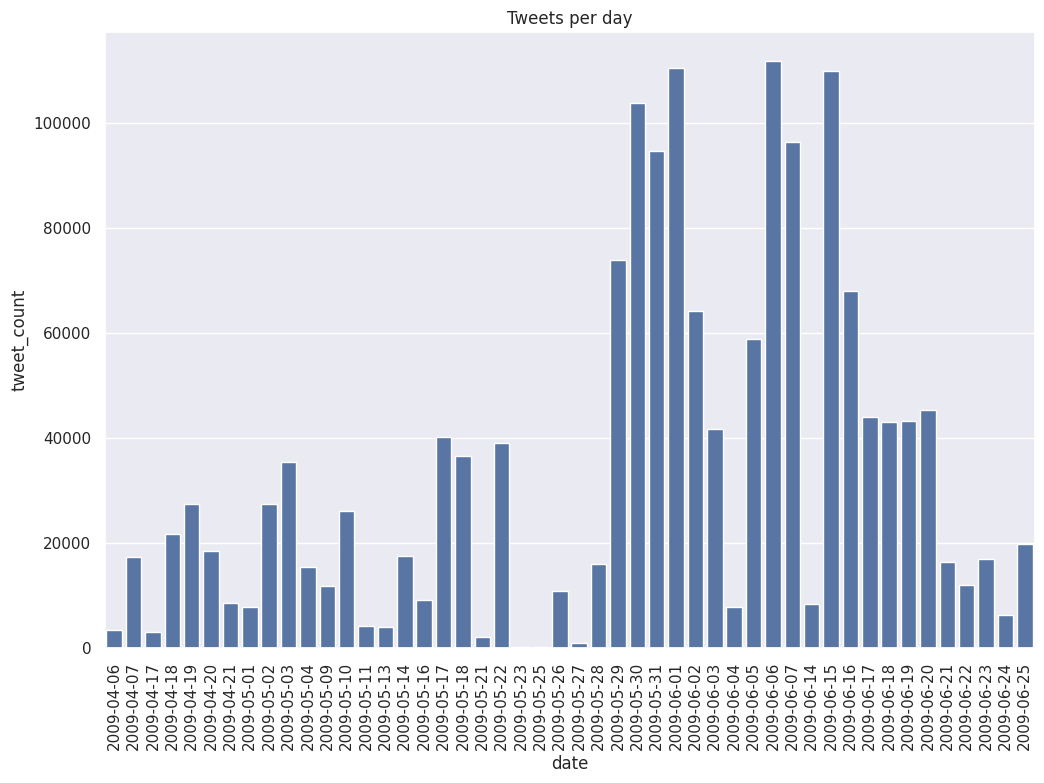

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

data = df.loc[:, ('id', 'date')].groupby(df['date'].dt.date).agg(tweet_count=('id', 'count')).reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(data=data, x='date', y='tweet_count')
plt.title(label='Tweets per day')
_ = plt.xticks(rotation=90)

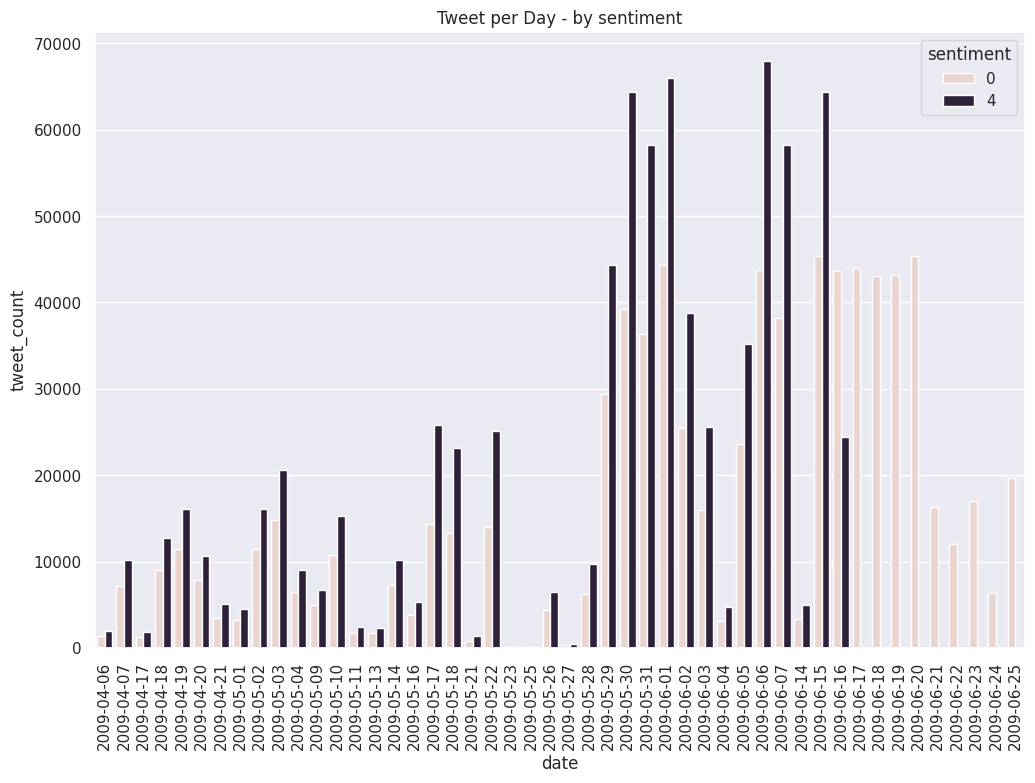

In [73]:
data = df.loc[:, ('id', 'date', 'sentiment')].groupby([df['date'].dt.date, 'sentiment']).agg(
    tweet_count=('id', 'count')).reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(data=data, x='date', y='tweet_count', hue='sentiment')
plt.title(label="Tweet per Day - by sentiment")
_ = plt.xticks(rotation=90)

##### Analyse `sentiment` Spalte

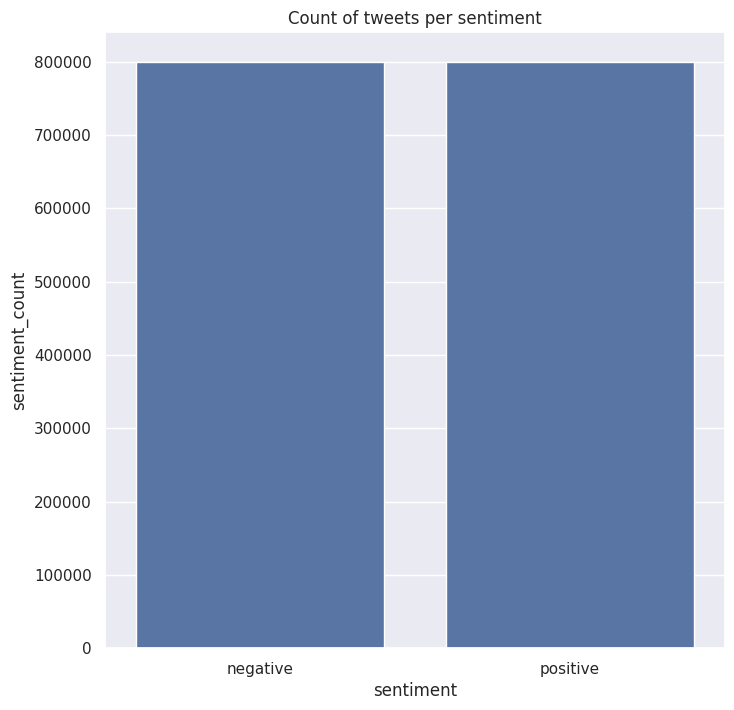

In [74]:
data = df.loc[:, ('id', 'sentiment')].groupby('sentiment').agg(sentiment_count=('id', 'count')).reset_index()
plt.figure(figsize=(8, 8))
sns.barplot(data=data, x='sentiment', y='sentiment_count')
plt.title(label='Count of tweets per sentiment')
new_labels = ['negative', 'positive']
_ = plt.xticks(ticks=range(len(new_labels)), labels=new_labels)

#### Testdaten

In [75]:
import pandas as pd
df_test = pd.read_csv(f"{DATASETS_ROOT_PATH}/{TEST_DATASET_FILE_NAME}", encoding='latin-1', names=DATASET_COLUMNS,
                      header=None,
                      converters={
                          'date': lambda date: parser.parse(date, tzinfos={'PDT': tz.gettz('America/Los Angeles')})})
df_test.info()  # keine fehlenden Werte

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype                  
---  ------     --------------  -----                  
 0   sentiment  498 non-null    int64                  
 1   id         498 non-null    int64                  
 2   date       498 non-null    datetime64[ns, tzutc()]
 3   query      498 non-null    object                 
 4   user       498 non-null    object                 
 5   text       498 non-null    object                 
dtypes: datetime64[ns, tzutc()](1), int64(2), object(3)
memory usage: 23.5+ KB


In [76]:
df_test.loc[df_test.text.str.contains('RT')]  # enthaltene Re-Tweets

,sentiment,id,date,query,user,text
38,4,124,2009-05-16 23:48:15+00:00,stanford,imusicmash,RT @jessverr I love the nerdy Stanford human biology videos - makes me miss school. http://bit.ly/13t7NR
67,4,172,2009-05-19 16:20:46+00:00,wolfram alpha,leedscentlib,RT @mashable: Five Things Wolfram Alpha Does Better (And Vastly Different) Than Google - http://bit.ly/6nSnR
72,0,177,2009-05-20 02:39:05+00:00,nike,coreysmbpro,RT @SmartChickPDX: Was just told that Nike layoffs started today :-(
110,4,237,2009-05-27 00:39:21+00:00,goodby silverstein,suedecrush,"RT @designplay Goodby, Silverstein's new site: http://www.goodbysilverstein.com/ I enjoy it. *nice find!*"
160,2,424,2009-06-02 03:27:48+00:00,gm,hammerauto,RT @LATimesautos is now the time to buy a GM car? http://bit.ly/nRzlu
164,0,428,2009-06-02 03:32:33+00:00,dentist,LILJIZZEL,"THE DENTIST LIED! "" U WON'T FEEL ANY DISCOMORT! PROB WON'T EVEN NEED PAIN PILLS"" MAN U TWIPPIN THIS SHIT HURT!! HOW MANY PILLS CAN I TAKE!!"
197,2,558,2009-06-07 01:14:08+00:00,jquery,marcroberts,RT @jquery: The Ultimate jQuery List - http://jquerylist.com/
203,4,564,2009-06-07 03:28:08+00:00,warren buffet,Alfred04654,"RT @blknprecious1: RT GREAT @dbroos ""Someone's sitting in the shade today because someone planted a tree a long time ago.""- Warren Buffet"
209,2,570,2009-06-07 21:38:42+00:00,kindle2,aqrinc,"RT Look, Available !Amazon Kindle2 &amp; Kindle DX, Get it Here: http://short.to/87ub The Top Electronic Book Reader Period, free 2 day ship ..."
277,4,2094,2009-05-17 15:04:55+00:00,Danny Gokey,fashion_retweet,"RT @PassionModel 'American Idol' fashion: Adam Lambert tones down, Danny Gokey cute ... http://cli.gs/7JWSHV"


In [77]:
id_to_sentiment_mapping = {0: 'negativ', 2: 'neutral', 4: 'positive'}

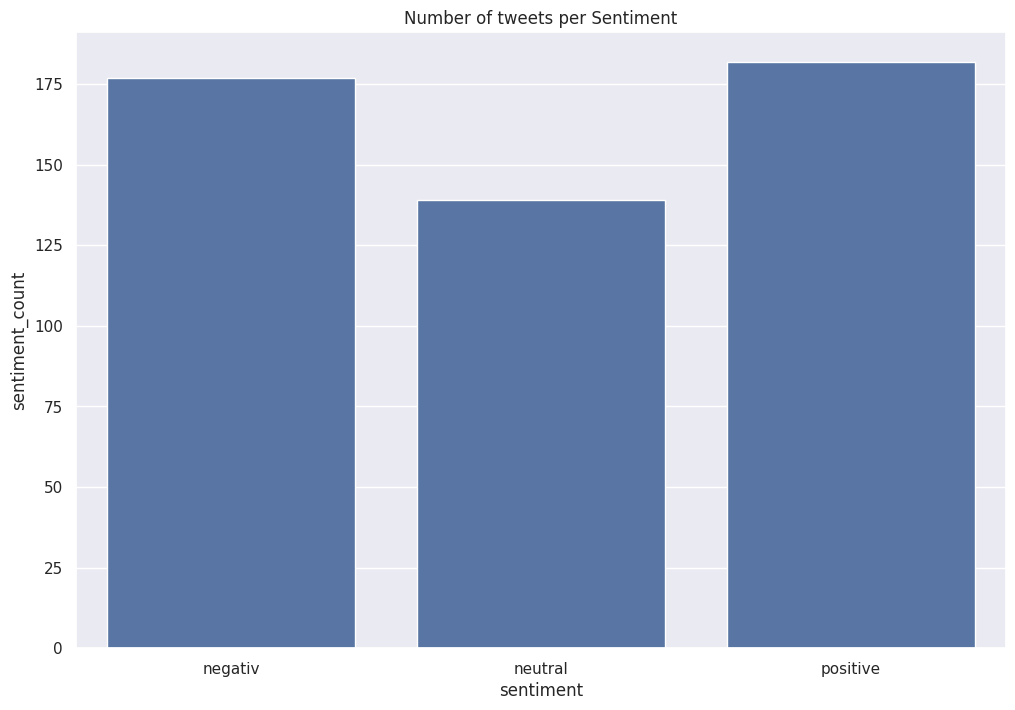

In [78]:
tmp_df = (
    df_test.loc[:, ["sentiment", "id"]]
    .groupby("sentiment")
    .agg(sentiment_count=("id", "count"))
).reset_index()

fig=plt.figure(figsize=(12,8))
ax = fig.subplots(1,1)
sns.barplot(tmp_df, x='sentiment', y='sentiment_count',ax=ax)
ax.set_xticks([0,1,2], id_to_sentiment_mapping.values())
ax.set_title('Number of tweets per Sentiment')
plt.show()

In [79]:
needed_set = {0, 4}


def both_sentiments_contained(x) -> int:
    diff = needed_set - set(x)
    return len(diff) == 0


query_keys = (
    df_test.loc[:, ["query", "sentiment"]]
    .groupby("query")
    .filter(lambda group: both_sentiments_contained(group["sentiment"]))["query"]
    .unique()
)
group_by_sentiment_and_query = df_test.loc[df_test["query"].isin(query_keys), ["sentiment", "query"]].groupby(
    "query"
).agg(average_sentiment=("sentiment", "mean"), number_of_tweets=("sentiment", "count")).sort_values(by=['average_sentiment', 'number_of_tweets' ], ascending=False).reset_index()
group_by_sentiment_and_query

,query,average_sentiment,number_of_tweets
0,kindle2,3.500000,20
1,obama,3.454545,11
2,mcdonalds,3.333333,6
3,lebron,3.111111,18
4,google,2.857143,7
5,Malcolm Gladwell,2.727273,11
6,"""night at the museum""",2.720000,25
7,"""booz allen""",2.666667,3
8,wolfram alpha,2.666667,3
9,nike,2.560000,25


<Figure size 1200x800 with 0 Axes>

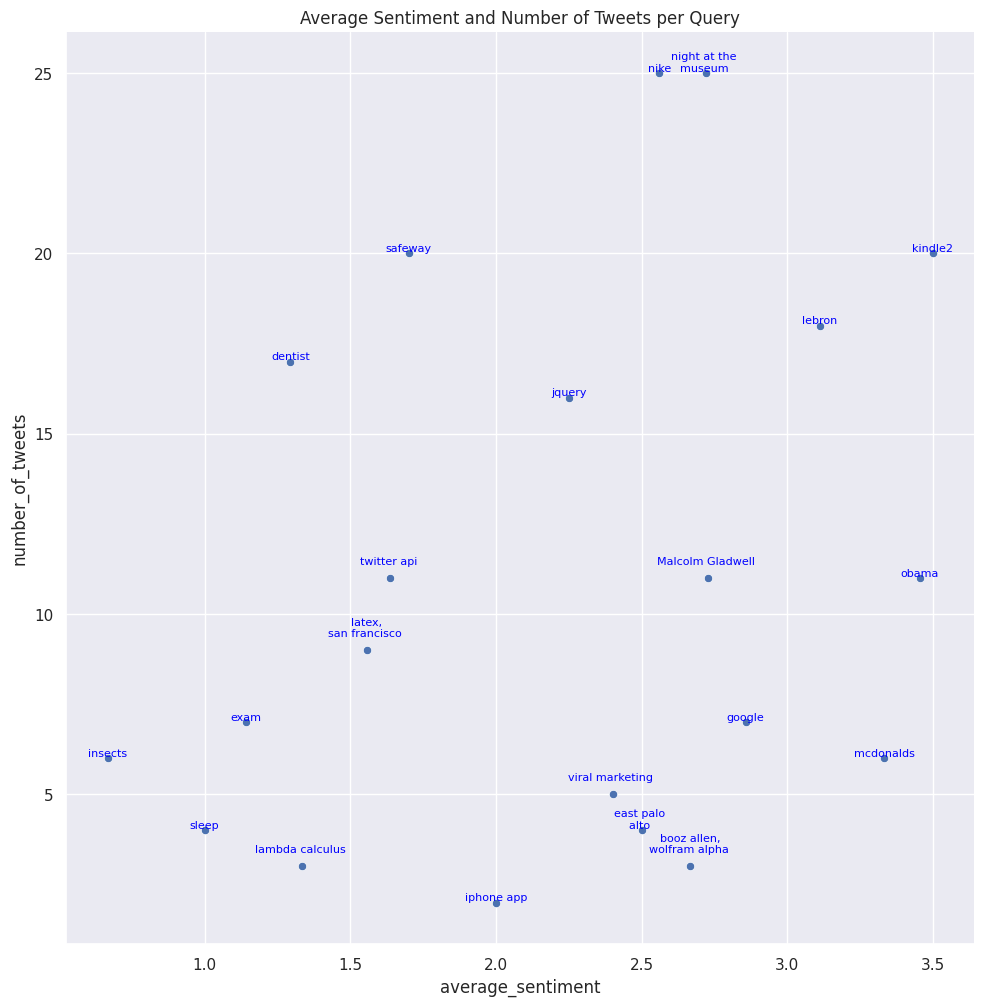

In [80]:
fig=plt.figure(figsize=(12,8))
g=sns.relplot(group_by_sentiment_and_query, x='average_sentiment',y= 'number_of_tweets', height=10)
g.ax.set_title('Average Sentiment and Number of Tweets per Query')

def format_query_key(key: str) -> str:
    key = key.replace('"', '')
    if len(key) > 10:
        words = key.split(' ')
        first_part = ''
        second_part = ''
        for word in words:
            if len(first_part) < 10:
                first_part +=  f"{word} "
            else:
                second_part += f"{word} "
        key = first_part + '\n' + second_part
    return key

for avg_sentiment in group_by_sentiment_and_query.average_sentiment.unique():
    relevant_rows = group_by_sentiment_and_query.loc[abs(group_by_sentiment_and_query.average_sentiment - avg_sentiment) < 1e-9,:]
    number_of_tweets = relevant_rows.number_of_tweets.unique()
    for n in number_of_tweets:
        queries = relevant_rows.loc[group_by_sentiment_and_query.number_of_tweets == n, 'query'].apply(lambda x: format_query_key(x)).to_list()
        ax = g.ax
        ax.text(avg_sentiment, n, ',\n'.join(queries), fontsize=8, ha="center", va="bottom", color="blue")

plt.show()

### Speicherung Daten

In [ ]:
df = df.drop(columns=['id', 'user', 'query', 'date'])
df.to_parquet(TRAIN_DATASET_FILE_PATH)

df_test = df_test.drop(columns=['user', 'id', 'date'])
df_test.to_parquet(TEST_DATASET_FILE_PATH)